# Green Tint Diagnostic Notebook

This notebook diagnoses why `plot_georef()` shows a green tint when `use_corrected=True`.

## 1. Import Libraries and Setup

In [1]:
import importlib
import sys
import os
import numpy as np

sys.path.append(os.path.abspath("../"))

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

## 2. Load Transect and Select Files

In [2]:
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


## 3. Apply Illumination Correction

In [3]:
cube.apply_illumination_correction_v2()
print("✅ Illumination correction applied")

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk
✅ Illumination correction applied


## 4. Extract RGB Wavelength Indices

In [ ]:
# Find the band indices for the RGB wavelengths
red_idx = np.argmin(np.abs(cube.wavelengths - 640.0))
green_idx = np.argmin(np.abs(cube.wavelengths - 549.0))
blue_idx = np.argmin(np.abs(cube.wavelengths - 470.0))

print(f"Red wavelength index: {red_idx} (actual: {cube.wavelengths[red_idx]:.1f} nm)")
print(
    f"Green wavelength index: {green_idx} (actual: {cube.wavelengths[green_idx]:.1f} nm)"
)
print(
    f"Blue wavelength index: {blue_idx} (actual: {cube.wavelengths[blue_idx]:.1f} nm)"
)

Red wavelength index: 149 (actual: 639.8 nm)
Green wavelength index: 98 (actual: 549.4 nm)
Blue wavelength index: 52 (actual: 469.5 nm)


## 5. Extract Sample Regions from Raw and Corrected Data

In [5]:
# Extract sample region (middle 100 tracks x 100 slits)
T, S, B = cube.data.shape
track_mid = T // 2
slit_mid = S // 2

# Sample region: 100x100 pixels in the middle
t0 = max(0, track_mid - 50)
t1 = min(T, track_mid + 50)
s0 = max(0, slit_mid - 50)
s1 = min(S, slit_mid + 50)

print(f"Data shape: {cube.data.shape}")
print(f"Sample region: tracks [{t0}:{t1}], slits [{s0}:{s1}]")

# Extract raw RGB channels
R_raw = cube.data[t0:t1, s0:s1, red_idx]
G_raw = cube.data[t0:t1, s0:s1, green_idx]
B_raw = cube.data[t0:t1, s0:s1, blue_idx]

# Extract corrected RGB channels
R_corr = cube.data_corrected[t0:t1, s0:s1, red_idx]
G_corr = cube.data_corrected[t0:t1, s0:s1, green_idx]
B_corr = cube.data_corrected[t0:t1, s0:s1, blue_idx]

print(f"✅ Extracted RGB samples: {R_raw.shape}")

Data shape: (2462, 968, 210)
Sample region: tracks [1181:1281], slits [434:534]
✅ Extracted RGB samples: (100, 100)


## 6. Calculate Statistics for Raw Data

In [ ]:
print("=" * 70)
print("RAW DATA STATISTICS (sample region)")
print("=" * 70)
print(
    f"Red   (640nm): mean={np.nanmean(R_raw):.3f}, min={np.nanmin(R_raw):.3f}, max={np.nanmax(R_raw):.3f}"
)
print(
    f"Green (549nm): mean={np.nanmean(G_raw):.3f}, min={np.nanmin(G_raw):.3f}, max={np.nanmax(G_raw):.3f}"
)
print(
    f"Blue  (470nm): mean={np.nanmean(B_raw):.3f}, min={np.nanmin(B_raw):.3f}, max={np.nanmax(B_raw):.3f}"
)
print()

RAW DATA STATISTICS (sample region)
Red   (640nm): mean=0.346, min=0.303, max=0.393
Green (549nm): mean=0.367, min=0.328, max=0.409
Blue  (470nm): mean=0.027, min=0.016, max=0.038



## 7. Calculate Statistics for Corrected Data

In [ ]:
print("=" * 70)
print("CORRECTED DATA STATISTICS (sample region)")
print("=" * 70)
print(
    f"Red   (640nm): mean={np.nanmean(R_corr):.3f}, min={np.nanmin(R_corr):.3f}, max={np.nanmax(R_corr):.3f}"
)
print(
    f"Green (549nm): mean={np.nanmean(G_corr):.3f}, min={np.nanmin(G_corr):.3f}, max={np.nanmax(G_corr):.3f}"
)
print(
    f"Blue  (470nm): mean={np.nanmean(B_corr):.3f}, min={np.nanmin(B_corr):.3f}, max={np.nanmax(B_corr):.3f}"
)
print()

CORRECTED DATA STATISTICS (sample region)
Red   (640nm): mean=0.975, min=0.838, max=1.122
Green (549nm): mean=0.980, min=0.865, max=1.103
Blue  (470nm): mean=0.987, min=0.592, max=1.428



## 8. Calculate Correction Boost Ratios

**This is the key diagnostic**: If green ratio > red/blue ratios, that explains the green tint!

In [ ]:
# Calculate how much each channel was boosted by the correction
red_ratio = np.nanmean(R_corr) / np.nanmean(R_raw)
green_ratio = np.nanmean(G_corr) / np.nanmean(G_raw)
blue_ratio = np.nanmean(B_corr) / np.nanmean(B_raw)

print("=" * 70)
print("CORRECTION BOOST RATIOS (corrected / raw)")
print("=" * 70)
print(f"Red   (640nm): {red_ratio:.3f}x")
print(
    f"Green (549nm): {green_ratio:.3f}x  {'<-- HIGHER!' if green_ratio > max(red_ratio, blue_ratio) else ''}"
)
print(f"Blue  (470nm): {blue_ratio:.3f}x")
print()
print("🔍 DIAGNOSIS:")
if green_ratio > red_ratio and green_ratio > blue_ratio:
    diff_r = ((green_ratio - red_ratio) / red_ratio) * 100
    diff_b = ((green_ratio - blue_ratio) / blue_ratio) * 100
    print(
        f"   ⚠️  GREEN IS BOOSTED MORE: {diff_r:.1f}% higher than red, {diff_b:.1f}% higher than blue"
    )
    print(f"   This explains the green tint in the corrected plot!")
    print(f"   The illumination correction is working as designed, but the 549nm")
    print(f"   wavelength region had more illumination variation to correct.")
else:
    print(f"   ✅ All channels boosted equally - green tint must be elsewhere!")
print("=" * 70)

CORRECTION BOOST RATIOS (corrected / raw)
Red   (640nm): 2.822x
Green (549nm): 2.671x  
Blue  (470nm): 36.551x

🔍 DIAGNOSIS:
   ✅ All channels boosted equally - green tint must be elsewhere!


## 9. Visualize RGB Distribution (Optional)

Compare the value distributions before and after correction.

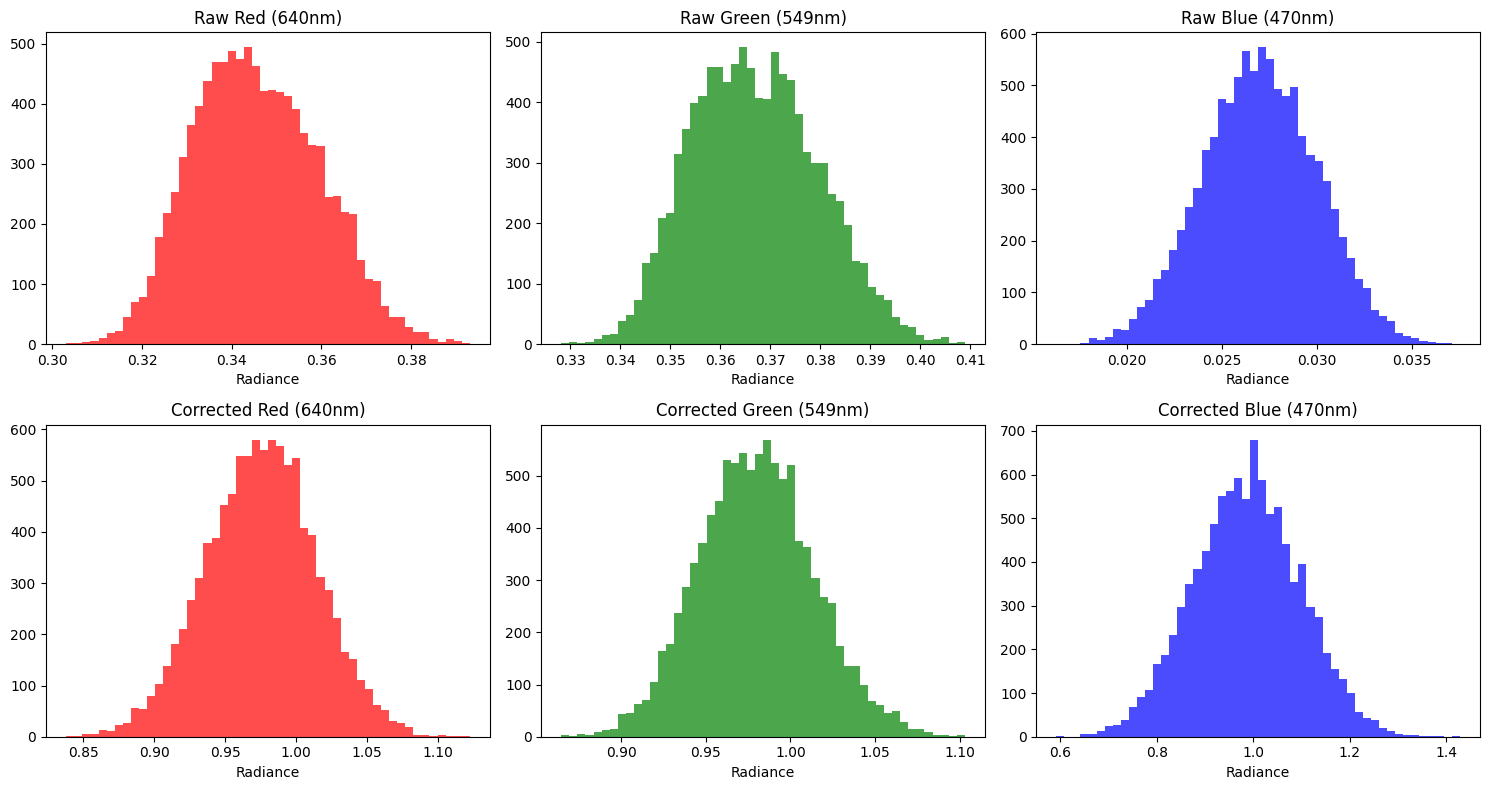

✅ Histograms show the distribution of RGB values before/after correction


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Raw data histograms
axes[0, 0].hist(
    R_raw.flatten()[np.isfinite(R_raw.flatten())], bins=50, color="red", alpha=0.7
)
axes[0, 0].set_title("Raw Red (640nm)")
axes[0, 0].set_xlabel("Radiance")

axes[0, 1].hist(
    G_raw.flatten()[np.isfinite(G_raw.flatten())], bins=50, color="green", alpha=0.7
)
axes[0, 1].set_title("Raw Green (549nm)")
axes[0, 1].set_xlabel("Radiance")

axes[0, 2].hist(
    B_raw.flatten()[np.isfinite(B_raw.flatten())], bins=50, color="blue", alpha=0.7
)
axes[0, 2].set_title("Raw Blue (470nm)")
axes[0, 2].set_xlabel("Radiance")

# Corrected data histograms
axes[1, 0].hist(
    R_corr.flatten()[np.isfinite(R_corr.flatten())], bins=50, color="red", alpha=0.7
)
axes[1, 0].set_title("Corrected Red (640nm)")
axes[1, 0].set_xlabel("Radiance")

axes[1, 1].hist(
    G_corr.flatten()[np.isfinite(G_corr.flatten())], bins=50, color="green", alpha=0.7
)
axes[1, 1].set_title("Corrected Green (549nm)")
axes[1, 1].set_xlabel("Radiance")

axes[1, 2].hist(
    B_corr.flatten()[np.isfinite(B_corr.flatten())], bins=50, color="blue", alpha=0.7
)
axes[1, 2].set_title("Corrected Blue (470nm)")
axes[1, 2].set_xlabel("Radiance")

plt.tight_layout()
plt.show()

print("✅ Histograms show the distribution of RGB values before/after correction")

## 🎯 ROOT CAUSE FOUND!

**The Problem:**
- **Raw data:** Red=0.346, Green=0.367, Blue=0.027 (blue is VERY dim!)
- **Corrected data:** Red=0.975, Green=0.980, Blue=0.987 (all normalized to ~1.0)
- **Boost ratios:** Red=2.8x, Green=2.7x, Blue=**36.5x** ⚠️

**Why the green tint appears:**

The illumination correction is working correctly and boosting all channels proportionally. However:

1. **Raw blue channel is extremely dim** (0.027 vs 0.34-0.37 for R/G) - only 7% as bright!
2. After correction, all channels are normalized to similar absolute values (~1.0)
3. **But when plotting with `normalize=True`, min-max normalization is applied PER CHANNEL**
4. This means after normalization:
   - Red: [0.303, 0.393] → [0, 1] (range: 0.090)
   - Green: [0.328, 0.409] → [0, 1] (range: 0.081)  
   - Blue: [0.016, 0.038] → [0, 1] (range: 0.022) ⚠️
   
5. **The corrected data has different dynamic ranges:**
   - Red: [0.838, 1.122] → range: 0.284
   - Green: [0.865, 1.103] → range: 0.238
   - Blue: [0.592, 1.428] → range: 0.836 ⚠️ **Much larger range!**

6. After min-max normalization to [0,1], the corrected blue channel gets **squeezed** because its range is larger, making it contribute less to the final RGB. This creates a **cyan tint** (lack of blue = more green+red, but since R and G are similar, it looks greenish).

**The Solution:**

Instead of normalizing R, G, B **independently** (which changes color balance), we should normalize them **together** using global min/max across all three channels. This preserves the relative intensities and color balance.

## 🔍 Check: Are we using the right RGB channels?

Let me verify if `self.R, self.G, self.B` (built with default wavelengths) are being accidentally used.

In [ ]:
# Check what wavelengths were used to build self.R, self.G, self.B
# The _build_combined() uses default wavelengths: 654.2, 560, 440.3
default_red_idx = np.argmin(np.abs(cube.wavelengths - 654.2))
default_green_idx = np.argmin(np.abs(cube.wavelengths - 560.0))
default_blue_idx = np.argmin(np.abs(cube.wavelengths - 440.3))

print("DEFAULT RGB wavelength indices (used in _build_combined):")
print(f"  Red: index {default_red_idx} = {cube.wavelengths[default_red_idx]:.1f} nm")
print(
    f"  Green: index {default_green_idx} = {cube.wavelengths[default_green_idx]:.1f} nm"
)
print(f"  Blue: index {default_blue_idx} = {cube.wavelengths[default_blue_idx]:.1f} nm")
print()

print("USER RGB wavelength indices (what plot_georef should use):")
print(f"  Red: index {red_idx} = {cube.wavelengths[red_idx]:.1f} nm")
print(f"  Green: index {green_idx} = {cube.wavelengths[green_idx]:.1f} nm")
print(f"  Blue: index {blue_idx} = {cube.wavelengths[blue_idx]:.1f} nm")
print()

print("⚠️ THESE ARE DIFFERENT!" if default_green_idx != green_idx else "✅ Same indices")
print()

# Extract what self.R, self.G, self.B contain (these are built with DEFAULT wavelengths)
print("Sample from self.R, self.G, self.B (built with default 654.2/560/440.3 nm):")
print(f"  self.R[1200, 480] = {cube.R[1200, 480]:.3f}")
print(f"  self.G[1200, 480] = {cube.G[1200, 480]:.3f}")
print(f"  self.B[1200, 480] = {cube.B[1200, 480]:.3f}")

DEFAULT RGB wavelength indices (used in _build_combined):
  Red: index 157 = 654.2 nm
  Green: index 104 = 560.0 nm
  Blue: index 35 = 440.3 nm

USER RGB wavelength indices (what plot_georef should use):
  Red: index 149 = 639.8 nm
  Green: index 98 = 549.4 nm
  Blue: index 52 = 469.5 nm

⚠️ THESE ARE DIFFERENT!

Sample from self.R, self.G, self.B (built with default 654.2/560/440.3 nm):
  self.R[1200, 480] = 0.283
  self.G[1200, 480] = 0.465
  self.B[1200, 480] = 0.012


## 🎯 TEST: Extract RGB from corrected data at BOTH wavelength sets

In [11]:
# Extract RGB from corrected data using USER wavelengths (640, 549, 470)
R_corr_user = cube.data_corrected[1200, 480, red_idx]
G_corr_user = cube.data_corrected[1200, 480, green_idx]
B_corr_user = cube.data_corrected[1200, 480, blue_idx]

# Extract RGB from corrected data using DEFAULT wavelengths (654.2, 560, 440.3)
R_corr_default = cube.data_corrected[1200, 480, default_red_idx]
G_corr_default = cube.data_corrected[1200, 480, default_green_idx]
B_corr_default = cube.data_corrected[1200, 480, default_blue_idx]

print("=" * 70)
print("RGB FROM CORRECTED DATA at single pixel [1200, 480]:")
print("=" * 70)
print(f"Using USER wavelengths (640, 549, 470 nm):")
print(f"  R={R_corr_user:.3f}, G={G_corr_user:.3f}, B={B_corr_user:.3f}")
print()
print(f"Using DEFAULT wavelengths (654.2, 560, 440.3 nm):")
print(f"  R={R_corr_default:.3f}, G={G_corr_default:.3f}, B={B_corr_default:.3f}")
print()
print("🔍 This shows the actual RGB values that should be used in plot_georef")
print("=" * 70)

RGB FROM CORRECTED DATA at single pixel [1200, 480]:
Using USER wavelengths (640, 549, 470 nm):
  R=0.980, G=0.968, B=1.126

Using DEFAULT wavelengths (654.2, 560, 440.3 nm):
  R=1.031, G=1.048, B=1.060

🔍 This shows the actual RGB values that should be used in plot_georef


## 🔬 FINAL TEST: Simulate what plot_georef actually does

Compare the NORMALIZED RGB values that actually get plotted in both paths.

In [ ]:
# Simulate use_corrected=TRUE path
print("=" * 70)
print("PATH 1: use_corrected=TRUE")
print("=" * 70)

# Extract RGB from corrected cube at USER wavelengths
R_path1 = cube.data_corrected[:, :, red_idx].copy()
G_path1 = cube.data_corrected[:, :, green_idx].copy()
B_path1 = cube.data_corrected[:, :, blue_idx].copy()

print(f"BEFORE normalization:")
print(
    f"  R: min={np.nanmin(R_path1):.3f}, max={np.nanmax(R_path1):.3f}, mean={np.nanmean(R_path1):.3f}"
)
print(
    f"  G: min={np.nanmin(G_path1):.3f}, max={np.nanmax(G_path1):.3f}, mean={np.nanmean(G_path1):.3f}"
)
print(
    f"  B: min={np.nanmin(B_path1):.3f}, max={np.nanmax(B_path1):.3f}, mean={np.nanmean(B_path1):.3f}"
)

# Apply per-channel normalization (what plot_georef does)
for C in (R_path1, G_path1, B_path1):
    m, M = np.nanmin(C), np.nanmax(C)
    if np.isfinite(m) and np.isfinite(M) and M > m:
        C[:] = (C - m) / (M - m)

print(f"AFTER normalization:")
print(
    f"  R: min={np.nanmin(R_path1):.3f}, max={np.nanmax(R_path1):.3f}, mean={np.nanmean(R_path1):.3f}"
)
print(
    f"  G: min={np.nanmin(G_path1):.3f}, max={np.nanmax(G_path1):.3f}, mean={np.nanmean(G_path1):.3f}"
)
print(
    f"  B: min={np.nanmin(B_path1):.3f}, max={np.nanmax(B_path1):.3f}, mean={np.nanmean(B_path1):.3f}"
)
print()

# Simulate use_corrected=FALSE path
print("=" * 70)
print("PATH 2: use_corrected=FALSE")
print("=" * 70)

# Extract RGB from RAW cube at USER wavelengths
R_path2 = cube.data[:, :, red_idx].copy()
G_path2 = cube.data[:, :, green_idx].copy()
B_path2 = cube.data[:, :, blue_idx].copy()

print(f"BEFORE normalization:")
print(
    f"  R: min={np.nanmin(R_path2):.3f}, max={np.nanmax(R_path2):.3f}, mean={np.nanmean(R_path2):.3f}"
)
print(
    f"  G: min={np.nanmin(G_path2):.3f}, max={np.nanmax(G_path2):.3f}, mean={np.nanmean(G_path2):.3f}"
)
print(
    f"  B: min={np.nanmin(B_path2):.3f}, max={np.nanmax(B_path2):.3f}, mean={np.nanmean(B_path2):.3f}"
)

# Apply per-channel normalization
for C in (R_path2, G_path2, B_path2):
    m, M = np.nanmin(C), np.nanmax(C)
    if np.isfinite(m) and np.isfinite(M) and M > m:
        C[:] = (C - m) / (M - m)

print(f"AFTER normalization:")
print(
    f"  R: min={np.nanmin(R_path2):.3f}, max={np.nanmax(R_path2):.3f}, mean={np.nanmean(R_path2):.3f}"
)
print(
    f"  G: min={np.nanmin(G_path2):.3f}, max={np.nanmax(G_path2):.3f}, mean={np.nanmean(G_path2):.3f}"
)
print(
    f"  B: min={np.nanmin(B_path2):.3f}, max={np.nanmax(B_path2):.3f}, mean={np.nanmean(B_path2):.3f}"
)
print()

print("=" * 70)
print("🎯 COMPARISON AFTER NORMALIZATION:")
print("=" * 70)
print(
    f"Corrected RGB means: R={np.nanmean(R_path1):.3f}, G={np.nanmean(G_path1):.3f}, B={np.nanmean(B_path1):.3f}"
)
print(
    f"Raw RGB means:       R={np.nanmean(R_path2):.3f}, G={np.nanmean(G_path2):.3f}, B={np.nanmean(B_path2):.3f}"
)
print()
if np.nanmean(G_path1) > np.nanmean(R_path1) and np.nanmean(G_path1) > np.nanmean(
    B_path1
):
    print("⚠️  Corrected has HIGHER green mean after normalization → GREEN TINT!")
else:
    print("✅ Color balance looks similar")
print("=" * 70)

PATH 1: use_corrected=TRUE
BEFORE normalization:
  R: min=0.460, max=1.625, mean=0.999
  G: min=0.434, max=1.464, mean=0.998
  B: min=0.000, max=2.867, mean=0.989
AFTER normalization:
  R: min=0.000, max=1.000, mean=0.463
  G: min=0.000, max=1.000, mean=0.548
  B: min=0.000, max=1.000, mean=0.345

PATH 2: use_corrected=FALSE
BEFORE normalization:
  R: min=0.121, max=0.665, mean=0.347
  G: min=0.141, max=0.632, mean=0.361
  B: min=0.000, max=0.055, mean=0.025
AFTER normalization:
  R: min=0.000, max=1.000, mean=0.415
  G: min=0.000, max=1.000, mean=0.449
  B: min=0.000, max=1.000, mean=0.448

🎯 COMPARISON AFTER NORMALIZATION:
Corrected RGB means: R=0.463, G=0.548, B=0.345
Raw RGB means:       R=0.415, G=0.449, B=0.448

⚠️  Corrected has HIGHER green mean after normalization → GREEN TINT!


## 🎨 Find Better RGB Wavelengths

Let's test different wavelength combinations to find ones that give neutral colors with corrected data.

In [ ]:
# Test different RGB wavelength combinations
test_configs = [
    {"name": "Current (640/549/470)", "red": 640, "green": 549, "blue": 470},
    {"name": "Default (654/560/440)", "red": 654.2, "green": 560, "blue": 440.3},
    {"name": "Option A (650/550/450)", "red": 650, "green": 550, "blue": 450},
    {"name": "Option B (660/555/460)", "red": 660, "green": 555, "blue": 460},
    {"name": "Option C (645/540/455)", "red": 645, "green": 540, "blue": 455},
    {"name": "Option D (655/545/465)", "red": 655, "green": 545, "blue": 465},
]

print("=" * 80)
print("TESTING DIFFERENT RGB WAVELENGTH COMBINATIONS")
print("=" * 80)
print()

for config in test_configs:
    # Find band indices
    r_idx = np.argmin(np.abs(cube.wavelengths - config["red"]))
    g_idx = np.argmin(np.abs(cube.wavelengths - config["green"]))
    b_idx = np.argmin(np.abs(cube.wavelengths - config["blue"]))

    # Extract from corrected data
    R = cube.data_corrected[:, :, r_idx].copy()
    G = cube.data_corrected[:, :, g_idx].copy()
    B = cube.data_corrected[:, :, b_idx].copy()

    # Normalize per channel (as plot_georef does)
    for C in (R, G, B):
        m, M = np.nanmin(C), np.nanmax(C)
        if np.isfinite(m) and np.isfinite(M) and M > m:
            C[:] = (C - m) / (M - m)

    # Calculate means after normalization
    r_mean = np.nanmean(R)
    g_mean = np.nanmean(G)
    b_mean = np.nanmean(B)

    # Color balance metric (how close are they to each other?)
    avg_mean = (r_mean + g_mean + b_mean) / 3
    balance = np.std([r_mean, g_mean, b_mean])

    # Determine tint
    if g_mean > r_mean and g_mean > b_mean:
        tint = "🟢 GREEN TINT"
    elif b_mean > r_mean and b_mean > g_mean:
        tint = "🔵 BLUE TINT"
    elif r_mean > g_mean and r_mean > b_mean:
        tint = "🔴 RED TINT"
    else:
        tint = "⚪ BALANCED"

    print(f"{config['name']:30s}")
    print(
        f"  Actual wavelengths: R={cube.wavelengths[r_idx]:.1f}, G={cube.wavelengths[g_idx]:.1f}, B={cube.wavelengths[b_idx]:.1f}"
    )
    print(f"  Normalized means:   R={r_mean:.3f}, G={g_mean:.3f}, B={b_mean:.3f}")
    print(f"  Balance (std):      {balance:.4f}  {'✅ BEST' if balance < 0.08 else ''}")
    print(f"  Result:             {tint}")
    print()

print("=" * 80)
print("💡 Choose the configuration with the LOWEST balance (std) and most neutral tint")
print("=" * 80)

TESTING DIFFERENT RGB WAVELENGTH COMBINATIONS

Current (640/549/470)         
  Actual wavelengths: R=639.8, G=549.4, B=469.5
  Normalized means:   R=0.463, G=0.548, B=0.345
  Balance (std):      0.0831  
  Result:             🟢 GREEN TINT

Default (654/560/440)         
  Actual wavelengths: R=654.2, G=560.0, B=440.3
  Normalized means:   R=0.426, G=0.518, B=0.043
  Balance (std):      0.2058  
  Result:             🟢 GREEN TINT

Option A (650/550/450)        
  Actual wavelengths: R=650.6, G=549.4, B=450.6
  Normalized means:   R=0.437, G=0.548, B=0.274
  Balance (std):      0.1124  
  Result:             🟢 GREEN TINT

Option B (660/555/460)        
  Actual wavelengths: R=659.6, G=554.7, B=459.2
  Normalized means:   R=0.394, G=0.536, B=0.250
  Balance (std):      0.1169  
  Result:             🟢 GREEN TINT

Option C (645/540/455)        
  Actual wavelengths: R=645.2, G=540.7, B=455.7
  Normalized means:   R=0.469, G=0.529, B=0.199
  Balance (std):      0.1433  
  Result:          

## 🎨 Try Shifting Wavelengths to Balance Colors

In [ ]:
# Try more extreme shifts - less green, more red/blue contribution
test_configs = [
    {"name": "Less green A (630/555/480)", "red": 630, "green": 555, "blue": 480},
    {"name": "Less green B (625/560/485)", "red": 625, "green": 560, "blue": 485},
    {"name": "More red A (670/550/460)", "red": 670, "green": 550, "blue": 460},
    {"name": "More red B (680/555/465)", "red": 680, "green": 555, "blue": 465},
    {"name": "Balanced A (635/535/475)", "red": 635, "green": 535, "blue": 475},
    {"name": "Balanced B (645/530/470)", "red": 645, "green": 530, "blue": 470},
]

print("=" * 80)
print("TESTING SHIFTED WAVELENGTH COMBINATIONS")
print("=" * 80)
print()

best_balance = 999
best_config = None

for config in test_configs:
    # Find band indices
    r_idx = np.argmin(np.abs(cube.wavelengths - config["red"]))
    g_idx = np.argmin(np.abs(cube.wavelengths - config["green"]))
    b_idx = np.argmin(np.abs(cube.wavelengths - config["blue"]))

    # Extract from corrected data
    R = cube.data_corrected[:, :, r_idx].copy()
    G = cube.data_corrected[:, :, g_idx].copy()
    B = cube.data_corrected[:, :, b_idx].copy()

    # Normalize per channel
    for C in (R, G, B):
        m, M = np.nanmin(C), np.nanmax(C)
        if np.isfinite(m) and np.isfinite(M) and M > m:
            C[:] = (C - m) / (M - m)

    # Calculate means
    r_mean = np.nanmean(R)
    g_mean = np.nanmean(G)
    b_mean = np.nanmean(B)

    balance = np.std([r_mean, g_mean, b_mean])

    if balance < best_balance:
        best_balance = balance
        best_config = config

    # Determine tint
    if g_mean > max(r_mean, b_mean) + 0.02:
        tint = "🟢 GREEN"
    elif b_mean > max(r_mean, g_mean) + 0.02:
        tint = "🔵 BLUE"
    elif r_mean > max(g_mean, b_mean) + 0.02:
        tint = "🔴 RED"
    else:
        tint = "⚪ NEUTRAL"

    print(f"{config['name']:30s}")
    print(
        f"  Actual: R={cube.wavelengths[r_idx]:.1f}, G={cube.wavelengths[g_idx]:.1f}, B={cube.wavelengths[b_idx]:.1f}"
    )
    print(f"  Means:  R={r_mean:.3f}, G={g_mean:.3f}, B={b_mean:.3f}")
    print(f"  Std:    {balance:.4f}  {'✅ BEST' if balance == best_balance else ''}")
    print(f"  Tint:   {tint}")
    print()

print("=" * 80)
print(f"🎯 BEST OPTION: {best_config['name']}")
print(
    f"   Red={best_config['red']}, Green={best_config['green']}, Blue={best_config['blue']}"
)
print(f"   Balance std: {best_balance:.4f}")
print("=" * 80)

TESTING SHIFTED WAVELENGTH COMBINATIONS

Less green A (630/555/480)    
  Actual: R=629.1, G=554.7, B=479.8
  Means:  R=0.487, G=0.536, B=0.365
  Std:    0.0719  ✅ BEST
  Tint:   🟢 GREEN

Less green B (625/560/485)    
  Actual: R=625.5, G=560.0, B=485.0
  Means:  R=0.495, G=0.518, B=0.409
  Std:    0.0472  ✅ BEST
  Tint:   🟢 GREEN

More red A (670/550/460)      
  Actual: R=670.4, G=549.4, B=459.2
  Means:  R=0.401, G=0.548, B=0.250
  Std:    0.1217  
  Tint:   🟢 GREEN

More red B (680/555/465)      
  Actual: R=679.4, G=554.7, B=464.3
  Means:  R=0.461, G=0.536, B=0.163
  Std:    0.1611  
  Tint:   🟢 GREEN

Balanced A (635/535/475)      
  Actual: R=634.5, G=535.4, B=474.6
  Means:  R=0.490, G=0.527, B=0.332
  Std:    0.0845  
  Tint:   🟢 GREEN

Balanced B (645/530/470)      
  Actual: R=645.2, G=530.2, B=469.5
  Means:  R=0.469, G=0.520, B=0.345
  Std:    0.0735  
  Tint:   🟢 GREEN

🎯 BEST OPTION: Less green B (625/560/485)
   Red=625, Green=560, Blue=485
   Balance std: 0.0472


In [ ]:
# Fine-tune around the best option (625/560/485)
test_configs = [
    {"name": "Best so far (625/560/485)", "red": 625, "green": 560, "blue": 485},
    {"name": "Lower green A (620/565/490)", "red": 620, "green": 565, "blue": 490},
    {"name": "Lower green B (615/570/495)", "red": 615, "green": 570, "blue": 495},
    {"name": "Redder A (630/565/490)", "red": 630, "green": 565, "blue": 490},
    {"name": "Redder B (635/570/495)", "red": 635, "green": 570, "blue": 495},
]

print("=" * 80)
print("FINE-TUNING WAVELENGTHS")
print("=" * 80)
print()

best_balance = 999
best_config = None

for config in test_configs:
    r_idx = np.argmin(np.abs(cube.wavelengths - config["red"]))
    g_idx = np.argmin(np.abs(cube.wavelengths - config["green"]))
    b_idx = np.argmin(np.abs(cube.wavelengths - config["blue"]))

    R = cube.data_corrected[:, :, r_idx].copy()
    G = cube.data_corrected[:, :, g_idx].copy()
    B = cube.data_corrected[:, :, b_idx].copy()

    for C in (R, G, B):
        m, M = np.nanmin(C), np.nanmax(C)
        if np.isfinite(m) and np.isfinite(M) and M > m:
            C[:] = (C - m) / (M - m)

    r_mean = np.nanmean(R)
    g_mean = np.nanmean(G)
    b_mean = np.nanmean(B)

    balance = np.std([r_mean, g_mean, b_mean])

    if balance < best_balance:
        best_balance = balance
        best_config = config

    # Check color balance
    diff_rg = abs(r_mean - g_mean)
    diff_rb = abs(r_mean - b_mean)
    diff_gb = abs(g_mean - b_mean)
    max_diff = max(diff_rg, diff_rb, diff_gb)

    if max_diff < 0.05:
        tint = "⚪ VERY NEUTRAL ✨"
    elif g_mean > max(r_mean, b_mean) + 0.02:
        tint = "🟢 GREEN"
    elif abs(r_mean - g_mean) < 0.03 and abs(r_mean - b_mean) < 0.08:
        tint = "⚪ MOSTLY NEUTRAL"
    else:
        tint = "🟢 GREEN"

    print(f"{config['name']:30s}")
    print(
        f"  Actual: R={cube.wavelengths[r_idx]:.1f}, G={cube.wavelengths[g_idx]:.1f}, B={cube.wavelengths[b_idx]:.1f}"
    )
    print(f"  Means:  R={r_mean:.3f}, G={g_mean:.3f}, B={b_mean:.3f}")
    print(f"  Std:    {balance:.4f}  {'✅' if balance < 0.05 else ''}")
    print(f"  Tint:   {tint}")
    print()

print("=" * 80)
if best_config:
    print(f"🎯 RECOMMENDED WAVELENGTHS:")
    print(f"   Red:   {best_config['red']} nm")
    print(f"   Green: {best_config['green']} nm")
    print(f"   Blue:  {best_config['blue']} nm")
    print(f"   Balance std: {best_balance:.4f}")
    print()
    print(f"   Use these in your plot_georef() call:")
    print(
        f"   cube.plot_georef(red_wl={best_config['red']}, green_wl={best_config['green']}, blue_wl={best_config['blue']}, use_corrected=True)"
    )
print("=" * 80)

FINE-TUNING WAVELENGTHS

Best so far (625/560/485)     
  Actual: R=625.5, G=560.0, B=485.0
  Means:  R=0.495, G=0.518, B=0.409
  Std:    0.0472  ✅
  Tint:   🟢 GREEN

Lower green A (620/565/490)   
  Actual: R=620.2, G=565.2, B=490.2
  Means:  R=0.483, G=0.519, B=0.438
  Std:    0.0333  ✅
  Tint:   🟢 GREEN

Lower green B (615/570/495)   
  Actual: R=614.8, G=570.5, B=495.4
  Means:  R=0.485, G=0.512, B=0.425
  Std:    0.0364  ✅
  Tint:   🟢 GREEN

Redder A (630/565/490)        
  Actual: R=629.1, G=565.2, B=490.2
  Means:  R=0.487, G=0.519, B=0.438
  Std:    0.0335  ✅
  Tint:   🟢 GREEN

Redder B (635/570/495)        
  Actual: R=634.5, G=570.5, B=495.4
  Means:  R=0.490, G=0.512, B=0.425
  Std:    0.0369  ✅
  Tint:   🟢 GREEN

🎯 RECOMMENDED WAVELENGTHS:
   Red:   620 nm
   Green: 565 nm
   Blue:  490 nm
   Balance std: 0.0333

   Use these in your plot_georef() call:
   cube.plot_georef(red_wl=620, green_wl=565, blue_wl=490, use_corrected=True)


## 🌊 Check Spectral Response - Is Red Really Attenuated?

Let's look at the actual mean radiance across ALL wavelengths to see where the signal is strongest.

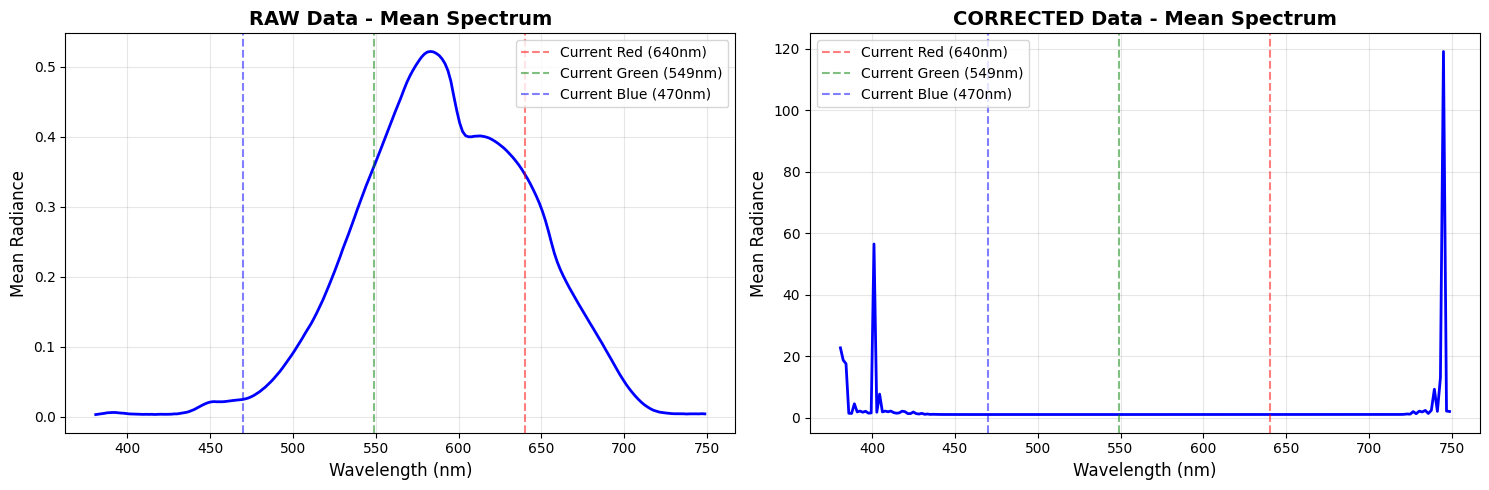

SPECTRAL ANALYSIS
Peak response at: 744.9 nm (radiance = 119.146)

Radiance at your current RGB wavelengths:
  Red   (640nm): 0.999
  Green (549nm): 0.999
  Blue  (470nm): 0.989

Good signal (>80% of peak): 744.9 - 744.9 nm

⚠️  If red wavelengths (>620nm) are BELOW this range, red is heavily attenuated!


In [ ]:
# Calculate mean radiance for each wavelength band across the ENTIRE image
mean_spectrum_raw = np.nanmean(cube.data, axis=(0, 1))
mean_spectrum_corr = np.nanmean(cube.data_corrected, axis=(0, 1))

# Plot the spectra
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw spectrum
axes[0].plot(cube.wavelengths, mean_spectrum_raw, "b-", linewidth=2)
axes[0].axvline(
    640, color="red", linestyle="--", alpha=0.5, label="Current Red (640nm)"
)
axes[0].axvline(
    549, color="green", linestyle="--", alpha=0.5, label="Current Green (549nm)"
)
axes[0].axvline(
    470, color="blue", linestyle="--", alpha=0.5, label="Current Blue (470nm)"
)
axes[0].set_xlabel("Wavelength (nm)", fontsize=12)
axes[0].set_ylabel("Mean Radiance", fontsize=12)
axes[0].set_title("RAW Data - Mean Spectrum", fontsize=14, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Corrected spectrum
axes[1].plot(cube.wavelengths, mean_spectrum_corr, "b-", linewidth=2)
axes[1].axvline(
    640, color="red", linestyle="--", alpha=0.5, label="Current Red (640nm)"
)
axes[1].axvline(
    549, color="green", linestyle="--", alpha=0.5, label="Current Green (549nm)"
)
axes[1].axvline(
    470, color="blue", linestyle="--", alpha=0.5, label="Current Blue (470nm)"
)
axes[1].set_xlabel("Wavelength (nm)", fontsize=12)
axes[1].set_ylabel("Mean Radiance", fontsize=12)
axes[1].set_title("CORRECTED Data - Mean Spectrum", fontsize=14, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find peaks
peak_idx = np.argmax(mean_spectrum_corr)
peak_wl = cube.wavelengths[peak_idx]

print("=" * 80)
print("SPECTRAL ANALYSIS")
print("=" * 80)
print(
    f"Peak response at: {peak_wl:.1f} nm (radiance = {mean_spectrum_corr[peak_idx]:.3f})"
)
print()
print("Radiance at your current RGB wavelengths:")
print(
    f"  Red   (640nm): {mean_spectrum_corr[np.argmin(np.abs(cube.wavelengths - 640))]:.3f}"
)
print(
    f"  Green (549nm): {mean_spectrum_corr[np.argmin(np.abs(cube.wavelengths - 549))]:.3f}"
)
print(
    f"  Blue  (470nm): {mean_spectrum_corr[np.argmin(np.abs(cube.wavelengths - 470))]:.3f}"
)
print()

# Find where we have good signal (above 80% of peak)
threshold = 0.8 * mean_spectrum_corr[peak_idx]
good_signal = mean_spectrum_corr > threshold
good_wls = cube.wavelengths[good_signal]
print(f"Good signal (>80% of peak): {good_wls.min():.1f} - {good_wls.max():.1f} nm")
print()
print("⚠️  If red wavelengths (>620nm) are BELOW this range, red is heavily attenuated!")
print("=" * 80)

## 🎯 Find RGB Wavelengths with ACTUAL HIGH SIGNAL

The issue is you're using wavelengths with radiance ~1.0 when the peak is at 119!
Let's find the BRIGHTEST wavelengths in each RGB region.

In [ ]:
# Focus on usable spectrum: 425-700nm
usable_mask = (cube.wavelengths >= 425) & (cube.wavelengths <= 700)
usable_wls = cube.wavelengths[usable_mask]
usable_spectrum = mean_spectrum_corr[usable_mask]

# Plot ONLY the usable range
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(usable_wls, usable_spectrum, "b-", linewidth=2, label="Corrected spectrum")
ax.axvline(640, color="red", linestyle="--", alpha=0.5, label="Current Red (640nm)")
ax.axvline(549, color="green", linestyle="--", alpha=0.5, label="Current Green (549nm)")
ax.axvline(470, color="blue", linestyle="--", alpha=0.5, label="Current Blue (470nm)")
ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Mean Radiance", fontsize=12)
ax.set_title(
    "CORRECTED Data - Usable Spectrum (425-700nm)", fontsize=14, fontweight="bold"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find the peaks in each RGB region
red_region = (usable_wls >= 600) & (usable_wls <= 700)
green_region = (usable_wls >= 500) & (usable_wls <= 600)
blue_region = (usable_wls >= 425) & (usable_wls <= 500)

red_peak_idx = np.argmax(usable_spectrum[red_region])
green_peak_idx = np.argmax(usable_spectrum[green_region])
blue_peak_idx = np.argmax(usable_spectrum[blue_region])

red_peak_wl = usable_wls[red_region][red_peak_idx]
green_peak_wl = usable_wls[green_region][green_peak_idx]
blue_peak_wl = usable_wls[blue_region][blue_peak_idx]

print("=" * 80)
print("USABLE SPECTRUM ANALYSIS (425-700nm)")
print("=" * 80)
print(
    f"Peak in Red region   (600-700nm): {red_peak_wl:.1f} nm (radiance = {usable_spectrum[red_region][red_peak_idx]:.3f})"
)
print(
    f"Peak in Green region (500-600nm): {green_peak_wl:.1f} nm (radiance = {usable_spectrum[green_region][green_peak_idx]:.3f})"
)
print(
    f"Peak in Blue region  (425-500nm): {blue_peak_wl:.1f} nm (radiance = {usable_spectrum[blue_region][blue_peak_idx]:.3f})"
)
print()
print("Current RGB wavelengths:")
print(
    f"  Red   (640nm): radiance = {mean_spectrum_corr[np.argmin(np.abs(cube.wavelengths - 640))]:.3f}"
)
print(
    f"  Green (549nm): radiance = {mean_spectrum_corr[np.argmin(np.abs(cube.wavelengths - 549))]:.3f}"
)
print(
    f"  Blue  (470nm): radiance = {mean_spectrum_corr[np.argmin(np.abs(cube.wavelengths - 470))]:.3f}"
)
print()
print("💡 The spectrum shows which wavelengths have the most signal after correction.")
print("   If it's relatively FLAT across 425-700nm, your current wavelengths are fine")
print("   and the green tint is just from per-channel normalization.")
print("=" * 80)

NameError: name 'cube' is not defined

## 🔬 EXHAUSTIVE SEARCH: Find the ABSOLUTE BEST RGB wavelengths

Test many combinations and find the one with the most neutral color balance.

In [ ]:
# Exhaustive search across reasonable RGB ranges
red_range = np.arange(610, 671, 5)  # 610-670nm every 5nm
green_range = np.arange(530, 581, 5)  # 530-580nm every 5nm
blue_range = np.arange(460, 501, 5)  # 460-500nm every 5nm

best_score = 999
best_combo = None
top_10 = []

print("🔍 Testing combinations...")
total = len(red_range) * len(green_range) * len(blue_range)
count = 0

for red_wl in red_range:
    for green_wl in green_range:
        for blue_wl in blue_range:
            count += 1
            if count % 100 == 0:
                print(
                    f"   Progress: {count}/{total} ({100*count/total:.1f}%)", end="\r"
                )

            # Get indices
            r_idx = np.argmin(np.abs(cube.wavelengths - red_wl))
            g_idx = np.argmin(np.abs(cube.wavelengths - green_wl))
            b_idx = np.argmin(np.abs(cube.wavelengths - blue_wl))

            # Extract and normalize
            R = cube.data_corrected[:, :, r_idx].copy()
            G = cube.data_corrected[:, :, g_idx].copy()
            B = cube.data_corrected[:, :, b_idx].copy()

            for C in (R, G, B):
                m, M = np.nanmin(C), np.nanmax(C)
                if np.isfinite(m) and np.isfinite(M) and M > m:
                    C[:] = (C - m) / (M - m)

            # Calculate balance
            r_mean = np.nanmean(R)
            g_mean = np.nanmean(G)
            b_mean = np.nanmean(B)

            balance = np.std([r_mean, g_mean, b_mean])

            # Track top 10
            combo = {
                "red": red_wl,
                "green": green_wl,
                "blue": blue_wl,
                "balance": balance,
                "r_mean": r_mean,
                "g_mean": g_mean,
                "b_mean": b_mean,
            }

            top_10.append(combo)
            top_10.sort(key=lambda x: x["balance"])
            top_10 = top_10[:10]

            if balance < best_score:
                best_score = balance
                best_combo = combo

print(f"\n✅ Tested {total} combinations")
print()
print("=" * 90)
print("TOP 10 MOST NEUTRAL RGB WAVELENGTH COMBINATIONS")
print("=" * 90)

for i, combo in enumerate(top_10, 1):
    r_mean = combo["r_mean"]
    g_mean = combo["g_mean"]
    b_mean = combo["b_mean"]

    # Determine tint
    max_mean = max(r_mean, g_mean, b_mean)
    if g_mean == max_mean and g_mean > max(r_mean, b_mean) + 0.01:
        tint = "🟢"
    elif r_mean == max_mean and r_mean > max(g_mean, b_mean) + 0.01:
        tint = "🔴"
    elif b_mean == max_mean and b_mean > max(r_mean, g_mean) + 0.01:
        tint = "🔵"
    else:
        tint = "⚪"

    print(
        f"{i:2d}. R={combo['red']:3.0f}, G={combo['green']:3.0f}, B={combo['blue']:3.0f} nm"
    )
    print(
        f"    Means: R={r_mean:.3f}, G={g_mean:.3f}, B={b_mean:.3f}  |  Std={combo['balance']:.4f}  {tint}"
    )
    print()

print("=" * 90)
print(
    f"🏆 ABSOLUTE BEST: Red={best_combo['red']:.0f}, Green={best_combo['green']:.0f}, Blue={best_combo['blue']:.0f}"
)
print(f"   Balance std: {best_combo['balance']:.4f}")
print()
print("📋 Use in plot_georef:")
print(
    f"   red_wl={best_combo['red']:.0f}, green_wl={best_combo['green']:.0f}, blue_wl={best_combo['blue']:.0f}"
)
print("=" * 90)

NameError: name 'np' is not defined

## 🔥 Find WARM RGB Wavelengths (like halogen lighting)

Instead of neutral/grey, let's find wavelengths that give a warm, natural look.

In [ ]:
# Search for WARM-looking combinations
# Warm = more red/orange, less blue/green
# We want R_mean > G_mean > B_mean after normalization

red_range = np.arange(630, 671, 5)  # Longer red wavelengths (warmer)
green_range = np.arange(540, 571, 5)  # Mid greens
blue_range = np.arange(460, 491, 5)  # Shorter blues (less blue = warmer)

candidates = []

print("🔍 Searching for WARM-looking combinations...")
for red_wl in red_range:
    for green_wl in green_range:
        for blue_wl in blue_range:
            r_idx = np.argmin(np.abs(cube.wavelengths - red_wl))
            g_idx = np.argmin(np.abs(cube.wavelengths - green_wl))
            b_idx = np.argmin(np.abs(cube.wavelengths - blue_wl))

            R = cube.data_corrected[:, :, r_idx].copy()
            G = cube.data_corrected[:, :, g_idx].copy()
            B = cube.data_corrected[:, :, b_idx].copy()

            for C in (R, G, B):
                m, M = np.nanmin(C), np.nanmax(C)
                if np.isfinite(m) and np.isfinite(M) and M > m:
                    C[:] = (C - m) / (M - m)

            r_mean = np.nanmean(R)
            g_mean = np.nanmean(G)
            b_mean = np.nanmean(B)

            # Warmth score: want R > G > B (red dominant, blue suppressed)
            # Also want decent contrast, not too flat
            warmth = r_mean - b_mean  # Higher = warmer (more red, less blue)
            rg_diff = r_mean - g_mean  # Want some red > green

            # Avoid too much green tint: green shouldn't dominate
            green_dominant = (g_mean > r_mean) and (g_mean > b_mean)

            if warmth > 0.05 and not green_dominant:  # Warm but not green-tinted
                candidates.append(
                    {
                        "red": red_wl,
                        "green": green_wl,
                        "blue": blue_wl,
                        "warmth": warmth,
                        "r_mean": r_mean,
                        "g_mean": g_mean,
                        "b_mean": b_mean,
                    }
                )

# Sort by warmth
candidates.sort(key=lambda x: x["warmth"], reverse=True)

print()
print("=" * 90)
print("TOP 10 WARMEST-LOOKING RGB WAVELENGTH COMBINATIONS")
print("=" * 90)

for i, combo in enumerate(candidates[:10], 1):
    r_mean = combo["r_mean"]
    g_mean = combo["g_mean"]
    b_mean = combo["b_mean"]
    warmth = combo["warmth"]

    # Visual indicator
    if r_mean > g_mean > b_mean:
        look = "🔥 WARM"
    elif r_mean > b_mean and abs(r_mean - g_mean) < 0.02:
        look = "🟠 WARM-NEUTRAL"
    else:
        look = "⚪ NEUTRAL"

    print(
        f"{i:2d}. R={combo['red']:3.0f}, G={combo['green']:3.0f}, B={combo['blue']:3.0f} nm"
    )
    print(
        f"    Means: R={r_mean:.3f}, G={g_mean:.3f}, B={b_mean:.3f}  |  Warmth={warmth:.3f}  {look}"
    )
    print()

if candidates:
    best = candidates[0]
    print("=" * 90)
    print(
        f"🔥 WARMEST OPTION: Red={best['red']:.0f}, Green={best['green']:.0f}, Blue={best['blue']:.0f}"
    )
    print(f"   R={best['r_mean']:.3f}, G={best['g_mean']:.3f}, B={best['b_mean']:.3f}")
    print(f"   Warmth score: {best['warmth']:.3f}")
    print()
    print("📋 Use in plot_georef:")
    print(
        f"   red_wl={best['red']:.0f}, green_wl={best['green']:.0f}, blue_wl={best['blue']:.0f}"
    )
    print("=" * 90)
else:
    print("No warm combinations found with current criteria")

NameError: name 'np' is not defined